# 02 — Zaman Serisi Analizi

TÜBİTAK IoB projesi kapsamında, oturum-hava birleşik veri setinin **günlük frekansa** indirgenmesi ve zaman serisinin matematiksel yapısının (trend, mevsimsellik, kalıntı) ile hava durumu şoklarının **gecikmeli etkilerinin** (CCF) incelenmesi.

**Veri:** `Veriler/oturum_hava_temiz_2021_sonrasi.csv` (120.749 oturum)

**Çıktı:** `Outputs/Analizler/02_zaman_serisi/`


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "Veriler" / "oturum_hava_temiz_2021_sonrasi.csv"
OUTPUT_DIR = PROJECT_ROOT / "Outputs" / "Analizler" / "02_zaman_serisi"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DECOMP_PERIOD = 7  # haftalik dongu (gunluk frekans)
MAX_CCF_LAG = 14
ADF_LAGS = 30
DPI = 200

if not DATA_PATH.exists():
    raise FileNotFoundError("Temiz veri yok. Once 00_veri_hazirlama_2021_sonrasi.ipynb calistirin.")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["acilis_datetime", "kapama_datetime", "tarih", "merge_saati"],
)
df["tarih"] = pd.to_datetime(df["tarih"]).dt.normalize()

_masa_labels = df["masa_grup"].dropna().unique().tolist()
BAHCE_LABEL = next(m for m in _masa_labels if "Bah" in m)
PAKET_LABEL = next(m for m in _masa_labels if "Paket" in m)

print("Veri:", df.shape)
print("Tarih:", df["tarih"].min().date(), "->", df["tarih"].max().date())
print("Masa gruplari:", _masa_labels)


Veri: (120749, 66)
Tarih: 2021-01-02 -> 2025-05-28
Masa gruplari: ['Bahçe', 'İç Salon', 'Paket']


## ADIM 1: Günlük Zaman Serisi Frekansı ve Model Seçim Gerekçesi

### Neden bu yöntemi seçtik?

Oturum düzeyindeki (transaction-level) gözlemler, aynı gün içinde saat ve öğün düzeyinde yoğun **mikro-yapısal gürültü** taşır; bu gürültü trend ve mevsimsellik bileşenlerinin istatistiksel olarak ayırt edilmesini zorlaştırır (Hyndman & Athanasopoulos, 2021). Zaman serisi ayrıştırması (`seasonal_decompose`), birim kök testleri (ADF) ve otokorelasyon fonksiyonlarının (ACF/PACF) geçerli yorumlanabilmesi için serinin **sabit frekanslı** (equispaced) bir zaman indeksine oturtulması gerekir (Hamilton, 1994).

Bu nedenle oturumları **günlük ('D') frekansa** indirgiyoruz. Agregasyon düzeyinde:
- **Sipariş sayısı** (count): talep hacmini ölçer;
- **Toplam miktar** (sum): sepet büyüklüğünün günlük toplamı;
- **Ortalama oturum süresi** ve **deflate tutar** (mean): davranışsal yoğunluk göstergeleri.

İşletmenin kapalı olduğu veya veri eksikliği nedeniyle oluşan **eksik günler**, ACF ve CCF hesaplarında lag hizasını bozar. Sürekliliği sağlamak için takvim eksiklerini tamamlayıp sayısal sütunlara **zaman esaslı doğrusal interpolasyon** (`interpolate(method='time')`) uyguluyoruz. Bu yaklaşım, kısa aralıklı boşluklarda Box-Jenkins çerçevesindeki süreklilik varsayımını korur; uzun kapalı dönemler kalıntı bileşeninde ayrıca yorumlanmalıdır.


In [2]:
# --- ADIM 1: Gunluk agregasyon ---
daily = (
    df.groupby("tarih", observed=True)
    .agg(
        siparis_adedi=("CEKNO", "size"),
        toplam_miktar=("toplam_miktar", "sum"),
        oturum_sure_dk=("oturum_sure_dk", "mean"),
        toplam_tutar_deflate_2021=("toplam_tutar_deflate_2021", "mean"),
        ort_sicaklik=("temperature_2m", "mean"),
        toplam_yagis=("precipitation", "sum"),
    )
    .sort_index()
)

# Masa grubu gunluk oranlari (%)
masa_gun = df.groupby(["tarih", "masa_grup"], observed=True).size().unstack(fill_value=0)
masa_pct = masa_gun.div(masa_gun.sum(axis=1), axis=0) * 100
daily["bahce_tercih_pct"] = masa_pct[BAHCE_LABEL]
daily["paket_oran_pct"] = masa_pct[PAKET_LABEL]

# Eksik gunleri tamamla ve interpolasyon
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
ts = daily.reindex(full_idx)
missing_days = int(ts.isna().any(axis=1).sum())
ts = ts.interpolate(method="time", limit_direction="both")

ts.index.name = "tarih"
ts.to_csv(OUTPUT_DIR / "gunluk_zaman_serisi.csv", encoding="utf-8-sig")

print(f"Gunluk seri: {len(ts)} gun | Eksik gun (interpolasyon oncesi): {missing_days}")
print(ts.describe().round(2))
ts.head()


Gunluk seri: 1608 gun | Eksik gun (interpolasyon oncesi): 218
       siparis_adedi  toplam_miktar  oturum_sure_dk  \
count        1608.00        1608.00         1608.00   
mean           86.84         509.33           33.87   
std            31.75         202.04            8.78   
min             3.00          13.00           19.30   
25%            68.75         387.46           28.03   
50%            88.00         502.00           31.69   
75%           104.00         617.00           37.28   
max           290.00        1978.00           96.73   

       toplam_tutar_deflate_2021  ort_sicaklik  toplam_yagis  \
count                    1608.00       1608.00       1608.00   
mean                      175.07         16.73          7.93   
std                        53.86          7.85         23.27   
min                        60.50         -0.99          0.00   
25%                       126.55         10.52          0.00   
50%                       176.60         16.23          0.

,siparis_adedi,toplam_miktar,oturum_sure_dk,toplam_tutar_deflate_2021,ort_sicaklik,toplam_yagis,bahce_tercih_pct,paket_oran_pct
tarih,,,,,,,,
2021-01-02,25.0,174.0,55.000000,152.405739,13.188000,0.0,8.000000,88.000000
2021-01-03,15.0,94.0,62.933333,150.603494,10.073333,0.0,6.666667,93.333333
2021-01-04,52.0,228.0,56.865385,95.842954,13.617308,0.0,7.692308,92.307692
2021-01-05,57.0,250.0,44.421053,88.257442,13.110526,0.0,5.263158,91.228070
2021-01-06,128.0,606.0,26.578125,90.544440,12.186719,0.0,17.968750,80.468750


## ADIM 2: Zaman Serisi Ayrıştırması (Seasonal Decomposition)

### Neden bu yöntemi seçtik?

Müşteri trafiğindeki dalgalanmalar tek bir gözlemde birbirine karışmış **yapısal (trend), deterministik periyodik (mevsimsellik) ve stokastik (kalıntı)** bileşenlerden oluşur (Cleveland et al., 1990). Restoran sektöründe günlük talep, **hafta içi–hafta sonu** ritmi nedeniyle belirgin **7 günlük periyot** taşır; bu nedenle `period=7` ile klasik **additive seasonal_decompose** tercih edilmiştir.

STL (Seasonal-Trend decomposition using Loess) daha esnek olmakla birlikte, bu aşamada hocanın yönlendirdiği standart ayrıştırma ile trend–mevsimsellik–kalıntı ayrımını şeffaf biçimde raporluyoruz. Kalıntı bileşeni, hava şoku gibi modele girmeyen **anlık dışsal sokları** temsil eder ve ADIM 4'teki CCF analizine zemin hazırlar.

Ayrıştırma; günlük **sipariş adedi**, **toplam miktar** ve **ortalama oturum süresi** üzerinde tekrarlanır.


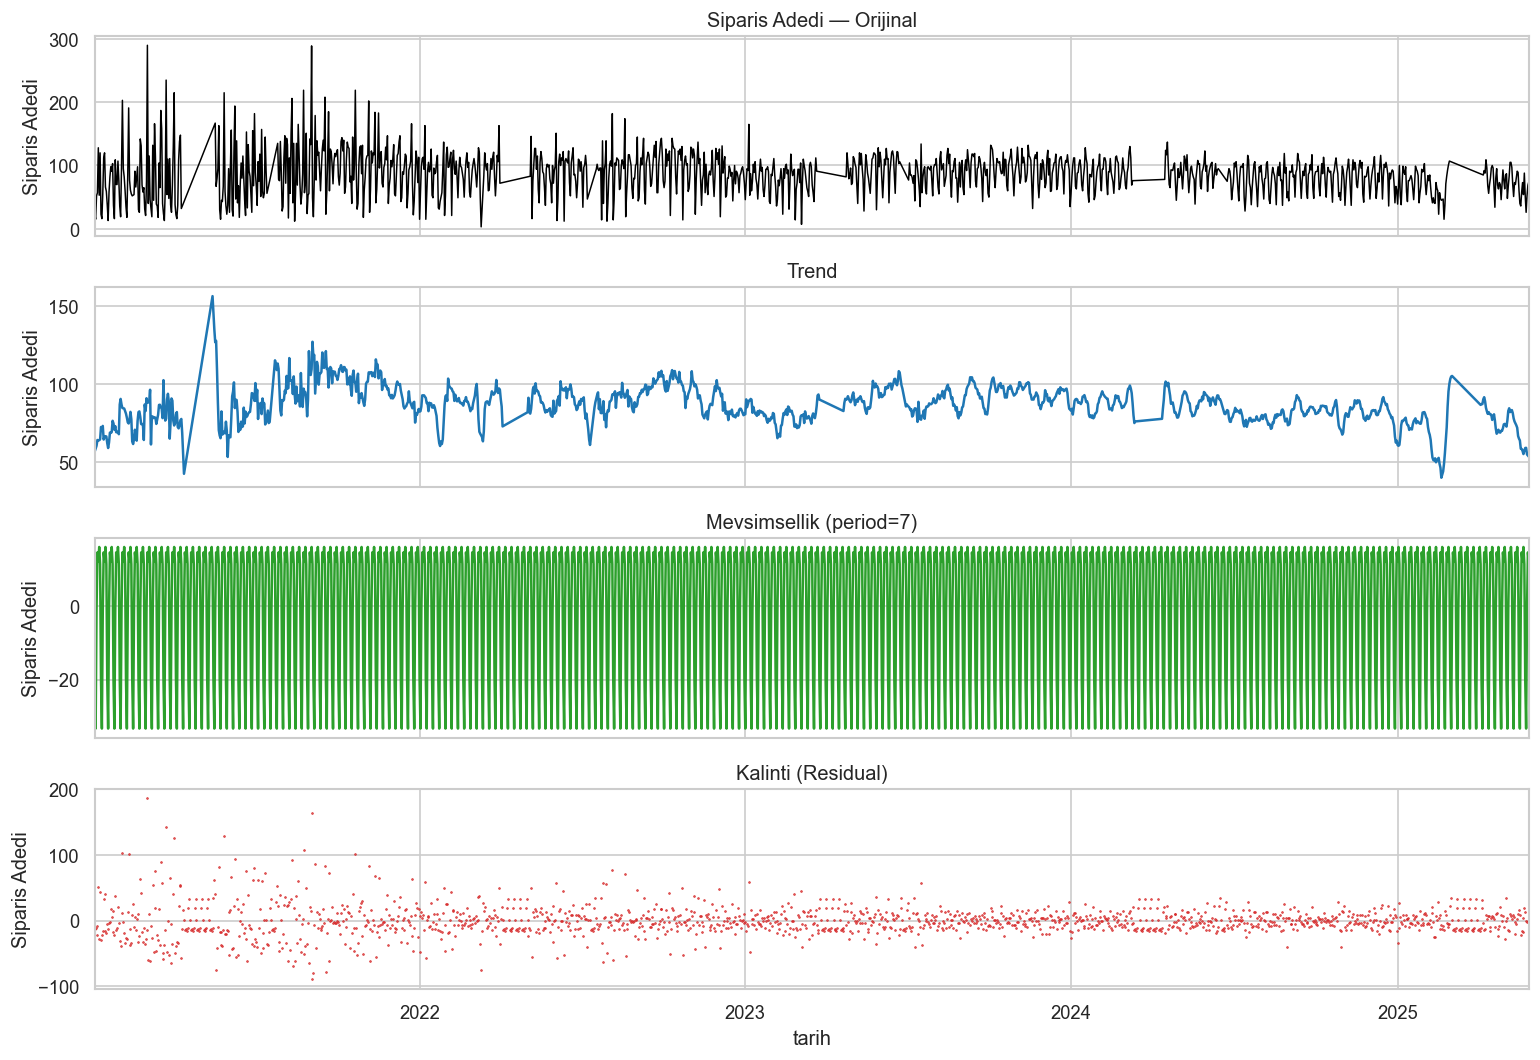

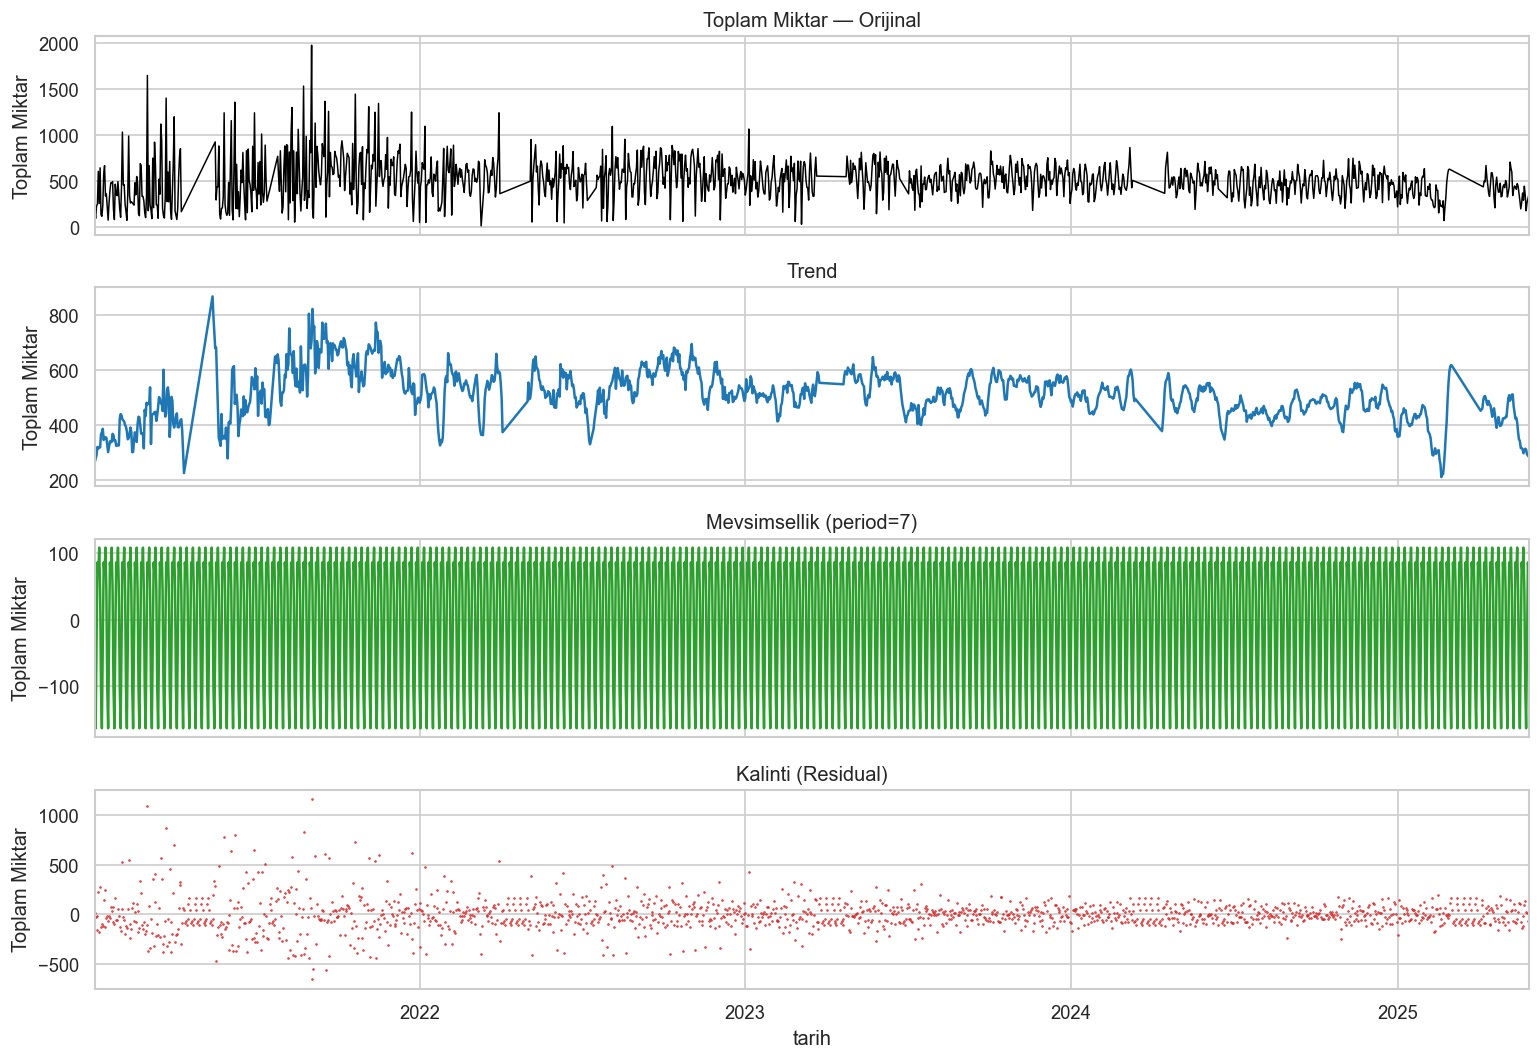

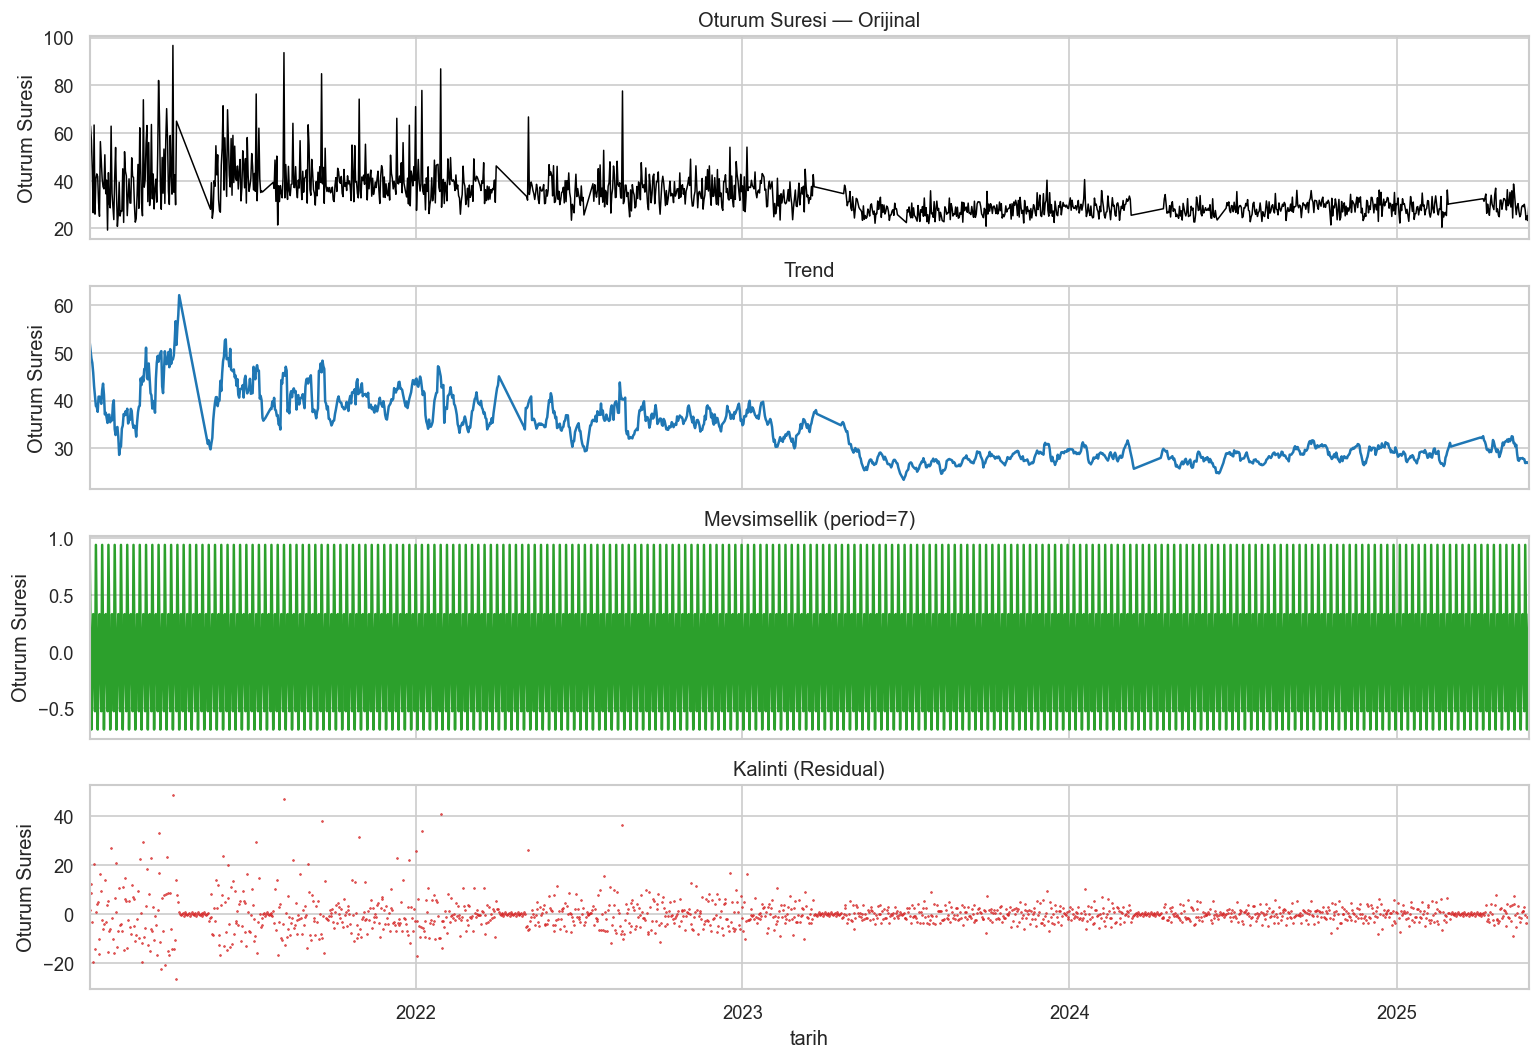

,seri,trend_std,seasonal_std,resid_std,seasonal_range
0,siparis_adedi,12.616939,17.963466,23.222837,49.435065
1,toplam_miktar,89.476440,96.510202,155.772864,272.715226
2,oturum_sure_dk,6.405789,0.503091,5.982937,1.628468


In [3]:
def run_decompose(series: pd.Series, name: str, period: int = DECOMP_PERIOD):
    """Additive seasonal decomposition; NaN kenar trendleri grafikte kalir."""
    s = series.dropna().astype(float)
    result = seasonal_decompose(s, model="additive", period=period, extrapolate_trend="freq")
    fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
    s.plot(ax=axes[0], color="black", linewidth=0.9, title=f"{name} — Orijinal")
    result.trend.plot(ax=axes[1], color="tab:blue", title="Trend")
    result.seasonal.plot(ax=axes[2], color="tab:green", title=f"Mevsimsellik (period={period})")
    result.resid.plot(ax=axes[3], color="tab:red", title="Kalinti (Residual)", marker=".", markersize=1, linestyle="None")
    for ax in axes:
        ax.set_ylabel(name)
    plt.tight_layout()
    fname = OUTPUT_DIR / f"decompose_{name.replace(' ', '_').lower()}.png"
    plt.savefig(fname, dpi=DPI, bbox_inches="tight")
    plt.show()
    return result


decomp_results = {}
for col, label in [
    ("siparis_adedi", "Siparis Adedi"),
    ("toplam_miktar", "Toplam Miktar"),
    ("oturum_sure_dk", "Oturum Suresi"),
]:
    decomp_results[col] = run_decompose(ts[col], label)

# Bilesen ozet istatistikleri
decomp_stats = []
for col, label in decomp_results.items():
    r = decomp_results[col]
    decomp_stats.append({
        "seri": col,
        "trend_std": float(r.trend.dropna().std()),
        "seasonal_std": float(r.seasonal.dropna().std()),
        "resid_std": float(r.resid.dropna().std()),
        "seasonal_range": float(r.seasonal.max() - r.seasonal.min()),
    })
decomp_df = pd.DataFrame(decomp_stats)
decomp_df.to_csv(OUTPUT_DIR / "decompose_bilesen_ozet.csv", index=False, encoding="utf-8-sig")
decomp_df


## ADIM 3: Durağanlık ve Bellek Analizi (ADF Testi, ACF & PACF)

### Neden bu yöntemi seçtik?

Zaman serisi modellerinin (ARIMA vb.) tutarlı tahmin üretebilmesi için serinin **durağan (stationary)** olması — yani birinci ve ikinci momentlerin (ortalama, varyans) zamanla sistematik biçimde değişmemesi — gerekir (Dickey & Fuller, 1979). **Augmented Dickey-Fuller (ADF)** testi, birim kök varlığını H₀: "seri durağan değildir" hipotezi altında sınamak için en yaygın kullanılan yöntemdir.

**Otokorelasyon Fonksiyonu (ACF)**, serinin kendi gecikmiş değerleriyle doğrusal ilişkisini; **Kısmi Otokorelasyon Fonksiyonu (PACF)** ise ara gecikmelerin etkisini kontrol ederek doğrudan belleği ortaya koyar (Box & Jenkins, 1976). Günlük sipariş serisinde 7. lag civarında tekrarlayan spike'lar haftalik mevsimselligi dogrular. En az **30 gecikme** incelenerek kisa ve orta vadeli hafiza yapisi raporlanir.


=== ADF Testi — Gunluk Siparis Adedi ===
Test istatistigi : -5.9168
p-deger         : 0.000000
Kullanilan lag  : 20
Gozlem sayisi   : 1587
Kritik degerler : {'1%': np.float64(-3.434), '5%': np.float64(-2.863), '10%': np.float64(-2.568)}

Yorum: Seri %5 anlamlilik duzeyinde DURAGAN (H0 reddedildi).


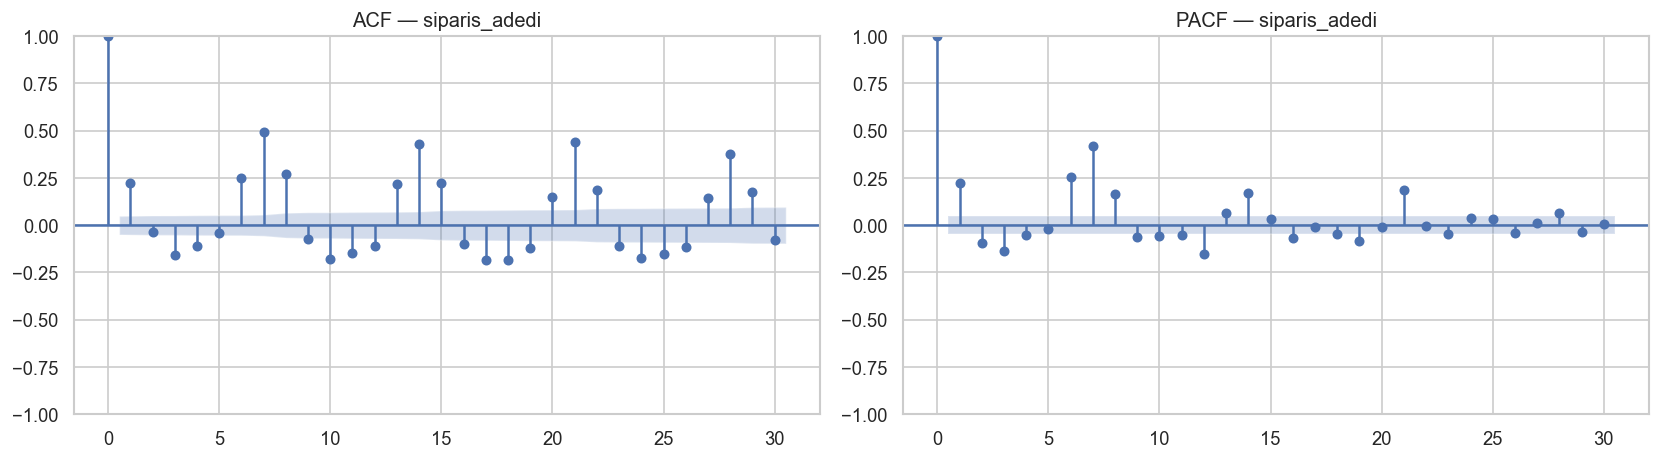

In [4]:
target = "siparis_adedi"
series_adf = ts[target].astype(float)

adf_out = adfuller(series_adf.dropna(), autolag="AIC")
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, adf_ic = adf_out

print("=== ADF Testi — Gunluk Siparis Adedi ===")
print(f"Test istatistigi : {adf_stat:.4f}")
print(f"p-deger         : {adf_p:.6f}")
print(f"Kullanilan lag  : {adf_lags}")
print(f"Gozlem sayisi   : {adf_nobs}")
print("Kritik degerler :", {k: round(v, 3) for k, v in adf_crit.items()})

# p < 0.05 -> H0 reddedilir -> durağan
if adf_p < 0.05:
    adf_yorum = "Seri %5 anlamlilik duzeyinde DURAGAN (H0 reddedildi)."
else:
    adf_yorum = "Seri DURAGAN DEGIL; fark alma (differencing) veya detrending gerekebilir."
print("\nYorum:", adf_yorum)

adf_record = {
    "seri": target,
    "adf_stat": round(float(adf_stat), 4),
    "p_deger": round(float(adf_p), 6),
    "lag": int(adf_lags),
    "nobs": int(adf_nobs),
    "duragan_005": bool(adf_p < 0.05),
    "yorum": adf_yorum,
}
pd.DataFrame([adf_record]).to_csv(OUTPUT_DIR / "adf_sonuc.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_adf.dropna(), lags=ADF_LAGS, ax=axes[0], alpha=0.05, title=f"ACF — {target}")
plot_pacf(series_adf.dropna(), lags=ADF_LAGS, ax=axes[1], alpha=0.05, method="ywm", title=f"PACF — {target}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "acf_pacf_siparis_adedi.png", dpi=DPI, bbox_inches="tight")
plt.show()


## ADIM 4: Hava Durumu Şokları ve Çapraz Korelasyon (CCF)

### Neden bu yöntemi seçtik?

Hava koşulları ile tüketici davranışı arasındaki ilişki **eşzamanlı (contemporaneous) olmak zorunda değildir**. Örneğin ani yağış veya sıcaklık düşüşü, aynı gün değil **ertesi gün(ler)** paket servis tercihini veya açık alan (bahçe) kullanımını etkileyebilir — bu **gecikmeli (lagged) etki** davranışsal IoB literatüründe sık raporlanır (Murphy & Bauman, 1992; Zheng et al., 2019).

**Çapraz Korelasyon Fonksiyonu (CCF)**, iki seri arasındaki korelasyonu farklı gecikme düzeylerinde (lag = 0, ±1, ±2, …) ölçerek optimal gecikmeyi belirlemeye olanak tanır (Chatfield, 2003). Bu analizde:

1. **Sıcaklık anomalisi** (trendden arındırılmış günlük ortalama sıcaklık) ↔ **Bahçe tercih oranı (%)**
2. **Günlük yağış miktarı** ↔ **Paket servis oranı (%)**

Sıcaklık anomalisini elde etmek için günlük ortalama sıcaklığın `seasonal_decompose` trend bileşenini çıkarıyoruz; böylece iklimsel uzun dönem eğilim ile kısa vadeli hava şokları ayrıştırılmış olur.


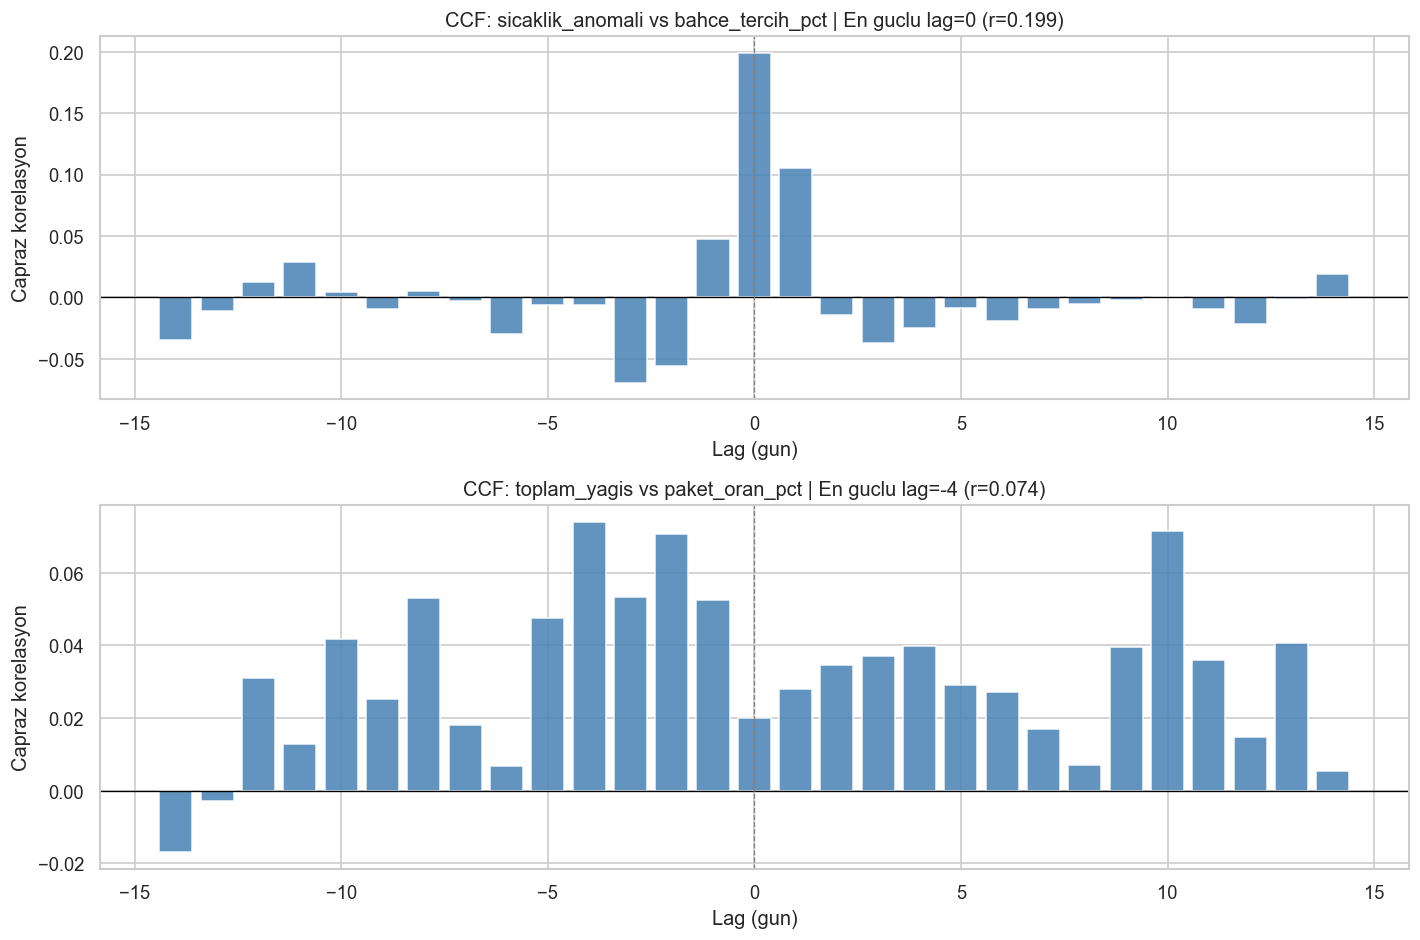

,analiz,x,y,en_guclu_lag,en_guclu_ccf
0,sicaklik_anomali_vs_bahce,sicaklik_anomali,bahce_tercih_pct,0,0.1993
1,yagis_vs_paket,toplam_yagis,paket_oran_pct,-4,0.0740


In [5]:
# Sicaklik anomalisi: trendden arindirilmis
temp_series = ts["ort_sicaklik"].astype(float)
temp_decomp = seasonal_decompose(
    temp_series, model="additive", period=DECOMP_PERIOD, extrapolate_trend="freq"
)
ts["sicaklik_anomali"] = temp_series - temp_decomp.trend
ts["sicaklik_anomali"] = ts["sicaklik_anomali"].interpolate(method="time")

ccf_vars = {
    "sicaklik_anomali_vs_bahce": ("sicaklik_anomali", "bahce_tercih_pct"),
    "yagis_vs_paket": ("toplam_yagis", "paket_oran_pct"),
}


def compute_ccf_table(x: pd.Series, y: pd.Series, max_lag: int = MAX_CCF_LAG) -> pd.DataFrame:
    """Lag 0..max_lag: corr(x_t, y_{t-lag}); negatif lag: corr(x_{t+|k|}, y_t)."""
    x = x.astype(float)
    y = y.astype(float)
    rows = []
    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            corr = x.corr(y.shift(lag))
        elif lag < 0:
            corr = x.shift(-lag).corr(y)
        else:
            corr = x.corr(y)
        rows.append({"lag": lag, "ccf": corr})
    return pd.DataFrame(rows)


ccf_summary = []

fig, axes = plt.subplots(len(ccf_vars), 1, figsize=(12, 4 * len(ccf_vars)))
if len(ccf_vars) == 1:
    axes = [axes]

for ax, (name, (xcol, ycol)) in zip(axes, ccf_vars.items()):
    tbl = compute_ccf_table(ts[xcol], ts[ycol], MAX_CCF_LAG)
    tbl.to_csv(OUTPUT_DIR / f"ccf_{name}.csv", index=False, encoding="utf-8-sig")

    best = tbl.loc[tbl["ccf"].abs().idxmax()]
    ccf_summary.append({
        "analiz": name,
        "x": xcol,
        "y": ycol,
        "en_guclu_lag": int(best["lag"]),
        "en_guclu_ccf": round(float(best["ccf"]), 4),
    })

    ax.bar(tbl["lag"], tbl["ccf"], color="steelblue", alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Lag (gun)")
    ax.set_ylabel("Capraz korelasyon")
    ax.set_title(f"CCF: {xcol} vs {ycol} | En guclu lag={int(best['lag'])} (r={best['ccf']:.3f})")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ccf_hava_masa_grubu.png", dpi=DPI, bbox_inches="tight")
plt.show()

ccf_summary_df = pd.DataFrame(ccf_summary)
ccf_summary_df.to_csv(OUTPUT_DIR / "ccf_ozet.csv", index=False, encoding="utf-8-sig")
ccf_summary_df


## ADIM 5: Çıktılar ve Raporlama

Bu hücrede üretilen istatistiksel özetler JSON formatında kaydedilir; grafikler `Outputs/Analizler/02_zaman_serisi/` klasöründe yüksek çözünürlüklü PNG olarak arşivlenmiştir.


In [6]:
ozet = {
    "kaynak": str(DATA_PATH.name),
    "gun_sayisi": int(len(ts)),
    "eksik_gun_interpolasyon": missing_days,
    "decompose_period": DECOMP_PERIOD,
    "adf": adf_record,
    "decompose_bilesen_std": decomp_df.to_dict(orient="records"),
    "ccf_en_guclu_lag": ccf_summary_df.to_dict(orient="records"),
}

with open(OUTPUT_DIR / "zaman_serisi_ozet.json", "w", encoding="utf-8") as f:
    json.dump(ozet, f, ensure_ascii=False, indent=2)

print("=== ZAMAN SERISI ANALIZI TAMAMLANDI ===")
print(f"ADF p-deger: {adf_record['p_deger']} -> {adf_record['yorum']}")
for row in ccf_summary:
    print(f"CCF {row['analiz']}: lag={row['en_guclu_lag']} gun, r={row['en_guclu_ccf']}")
print("\nCikti klasoru:", OUTPUT_DIR.resolve())


=== ZAMAN SERISI ANALIZI TAMAMLANDI ===
ADF p-deger: 0.0 -> Seri %5 anlamlilik duzeyinde DURAGAN (H0 reddedildi).
CCF sicaklik_anomali_vs_bahce: lag=0 gun, r=0.1993
CCF yagis_vs_paket: lag=-4 gun, r=0.074

Cikti klasoru: C:\Users\BUSRA\Documents\GitHub\IoBDataAnalysis\Outputs\Analizler\02_zaman_serisi
